In [3]:
pip install openpyxl

   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   --------- ------------------------------ 61.4/250.9 kB 1.1 MB/s eta 0:00:01
   ------------------------ --------------- 153.6/250.9 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 250.9/250.9 kB 1.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

In [3]:
file_path = "EduPro Online Platform.xlsx"

users = pd.read_excel(file_path, sheet_name="Users")
courses = pd.read_excel(file_path, sheet_name="Courses")
transactions = pd.read_excel(file_path, sheet_name="Transactions")
teachers = pd.read_excel(file_path, sheet_name="Teachers")

print(users.shape)
print(courses.shape)
print(transactions.shape)
print(teachers.shape)

(3000, 5)
(60, 8)
(10000, 7)
(60, 7)


In [11]:
# DATA INSPECTION
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   UserID    3000 non-null   str  
 1   UserName  3000 non-null   str  
 2   Age       3000 non-null   int64
 3   Gender    3000 non-null   str  
 4   Email     3000 non-null   str  
dtypes: int64(1), str(4)
memory usage: 117.3 KB


In [5]:
courses.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CourseID        60 non-null     str    
 1   CourseName      60 non-null     str    
 2   CourseCategory  60 non-null     str    
 3   CourseType      60 non-null     str    
 4   CourseLevel     60 non-null     str    
 5   CoursePrice     60 non-null     float64
 6   CourseDuration  60 non-null     float64
 7   CourseRating    60 non-null     float64
dtypes: float64(3), str(5)
memory usage: 3.9 KB


In [6]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    10000 non-null  str           
 1   UserID           10000 non-null  str           
 2   CourseID         10000 non-null  str           
 3   TransactionDate  10000 non-null  datetime64[us]
 4   Amount           10000 non-null  float64       
 5   PaymentMethod    10000 non-null  str           
 6   TeacherID        10000 non-null  str           
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 547.0 KB


In [7]:
teachers.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TeacherID          60 non-null     str    
 1   TeacherName        60 non-null     str    
 2   Age                60 non-null     int64  
 3   Gender             60 non-null     str    
 4   Expertise          60 non-null     str    
 5   YearsOfExperience  60 non-null     int64  
 6   TeacherRating      60 non-null     float64
dtypes: float64(1), int64(2), str(4)
memory usage: 3.4 KB


In [ ]:
# CHECK MISSING VALUES

print("Users")
print(users.isnull().sum())

print("\nCourses")
print(courses.isnull().sum())

print("\nTransactions")
print(transactions.isnull().sum())

print("\nTeachers")
print(teachers.isnull().sum())

Users
UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64

Courses
CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

Transactions
TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64

Teachers
TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64


In [ ]:
# CHECK DUPLICATES

print("Users duplicates:", users.duplicated().sum())
print("Courses duplicates:", courses.duplicated().sum())
print("Transactions duplicates:", transactions.duplicated().sum())
print("Teachers duplicates:", teachers.duplicated().sum())

Users duplicates: 0
Courses duplicates: 0
Transactions duplicates: 0
Teachers duplicates: 0


In [ ]:
# CHECK UNIQUE VALUES

print(users['Gender'].value_counts())
print(courses['CourseCategory'].value_counts())
print(courses['CourseLevel'].value_counts())
print(courses['CourseType'].value_counts())

Gender
Female    1520
Male      1480
Name: count, dtype: int64
CourseCategory
Programming                5
Design                     5
Business                   5
Marketing                  5
Data Science               5
Machine Learning           5
Cybersecurity              5
Project Management         5
Finance                    5
Artificial Intelligence    5
Web Development            5
Digital Marketing          5
Name: count, dtype: int64
CourseLevel
Beginner        21
Advanced        21
Intermediate    18
Name: count, dtype: int64
CourseType
Free    38
Paid    22
Name: count, dtype: int64


In [34]:
# CREATE MASTER DATASET

master_df = transactions.merge(courses,on="CourseID",how="left")

master_df = master_df.merge(users,on="UserID",how="left")

master_df = master_df.merge(teachers,on="TeacherID",how="left")

print(master_df.shape)
master_df.head()

(10000, 24)


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,UserName,Age_x,Gender_x,Email,TeacherName,Age_y,Gender_y,Expertise,YearsOfExperience,TeacherRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72,morrisonamanda,33,Female,ganderson@yahoo.com,Kimberly Miller,49,Male,Cybersecurity,24,4.58
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45,morrisonamanda,33,Female,ganderson@yahoo.com,Kimberly Miller,49,Male,Cybersecurity,24,4.58
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98,morrisonamanda,33,Female,ganderson@yahoo.com,Kimberly Miller,49,Male,Cybersecurity,24,4.58
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64,fthornton,23,Female,christensencatherine@outlook.com,Kimberly Miller,49,Male,Cybersecurity,24,4.58
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14,fthornton,23,Female,christensencatherine@outlook.com,Yolanda Levine,49,Female,Machine Learning,21,4.97


In [ ]:
# EDA

master_df["CourseCategory"].value_counts()


CourseCategory
Data Science               916
Finance                    864
Web Development            844
Business                   833
Project Management         829
Artificial Intelligence    829
Design                     827
Cybersecurity              819
Machine Learning           819
Digital Marketing          808
Marketing                  806
Programming                806
Name: count, dtype: int64

In [17]:
master_df["CourseLevel"].value_counts()

CourseLevel
Beginner        3573
Advanced        3475
Intermediate    2952
Name: count, dtype: int64

In [18]:
master_df["CourseType"].value_counts()

CourseType
Free    6403
Paid    3597
Name: count, dtype: int64

In [26]:
master_df.columns.tolist()

['TransactionID',
 'UserID',
 'CourseID',
 'TransactionDate',
 'Amount',
 'PaymentMethod',
 'TeacherID',
 'CourseName',
 'CourseCategory',
 'CourseType',
 'CourseLevel',
 'CoursePrice',
 'CourseDuration',
 'CourseRating',
 'UserName',
 'Age_x',
 'Gender_x',
 'Email',
 'TeacherName',
 'Age_y',
 'Gender_y',
 'Expertise',
 'YearsOfExperience',
 'TeacherRating']

In [27]:
master_df["Age_x"].describe()

count    10000.000000
mean        24.965700
std          6.051858
min         15.000000
25%         20.000000
50%         25.000000
75%         30.000000
max         35.000000
Name: Age_x, dtype: float64

In [35]:
master_df = master_df.rename(columns={"Age_x": "UserAge","Gender_x": "UserGender","Age_y": "TeacherAge","Gender_y": "TeacherGender"})

In [36]:
master_df.columns

Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID', 'CourseName', 'CourseCategory',
       'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration',
       'CourseRating', 'UserName', 'UserAge', 'UserGender', 'Email',
       'TeacherName', 'TeacherAge', 'TeacherGender', 'Expertise',
       'YearsOfExperience', 'TeacherRating'],
      dtype='str')

In [39]:
# FEATURE ENGINEERING

learner_features = pd.DataFrame()

# Total Courses Enrolled
learner_features["total_courses"] = (master_df.groupby("UserID")["CourseID"].count())

# Total Spending
learner_features["total_spending"] = (master_df.groupby("UserID")["Amount"].sum())

# Average Spending
learner_features["avg_spending"] = (master_df.groupby("UserID")["Amount"].mean())

# Diversity Score
learner_features["diversity_score"] = (master_df.groupby("UserID")["CourseCategory"].nunique())

# Preferred Category
preferred_category = (master_df.groupby("UserID")["CourseCategory"].agg(lambda x: x.mode()[0]))
learner_features["preferred_category"] = preferred_category

# Preferred Level
preferred_level = (master_df.groupby("UserID")["CourseLevel"].agg(lambda x: x.mode()[0]))
learner_features["preferred_level"] = preferred_level

# Average Course Rating
learner_features["avg_course_rating"] = (master_df.groupby("UserID")["CourseRating"].mean())

# User Age
user_age = (master_df.groupby("UserID")["UserAge"].first())
learner_features["user_age"] = user_age

# User Gender
user_gender = (master_df.groupby("UserID")["UserGender"].first())
learner_features["user_gender"] = user_gender


In [40]:
learner_features.head()

,total_courses,total_spending,avg_spending,diversity_score,preferred_category,preferred_level,avg_course_rating,user_age,user_gender
UserID,,,,,,,,,
U00001,1,394.26,394.260000,1,Cybersecurity,Intermediate,1.350000,15,Male
U00002,1,0.00,0.000000,1,Programming,Beginner,2.880000,29,Female
U00003,11,613.98,55.816364,7,Marketing,Advanced,2.889091,33,Female
U00004,13,982.05,75.542308,8,Digital Marketing,Intermediate,3.451538,23,Female
U00005,2,346.71,173.355000,2,Programming,Advanced,2.055000,21,Male


In [ ]:
learner_features.shape

(3000, 9)

In [45]:
# Encode Categorical Features

from sklearn.preprocessing import LabelEncoder

le_category = LabelEncoder()
le_level = LabelEncoder()
le_gender = LabelEncoder()

learner_features["preferred_category"] = (le_category.fit_transform(learner_features["preferred_category"]))
learner_features["preferred_level"] = (le_level.fit_transform(learner_features["preferred_level"]))
learner_features["user_gender"] = (le_gender.fit_transform(learner_features["user_gender"]))

learner_features.head()

,total_courses,total_spending,avg_spending,diversity_score,preferred_category,preferred_level,avg_course_rating,user_age,user_gender
UserID,,,,,,,,,
U00001,1,394.26,394.260000,1,2,2,1.350000,15,1
U00002,1,0.00,0.000000,1,9,1,2.880000,29,0
U00003,11,613.98,55.816364,7,8,0,2.889091,33,0
U00004,13,982.05,75.542308,8,5,2,3.451538,23,0
U00005,2,346.71,173.355000,2,9,0,2.055000,21,1


In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_features = scaler.fit_transform(learner_features)
scaled_features.shape

(3000, 9)

In [ ]:
# K-Means

from sklearn.cluster import KMeans

inertia = []
for k in range(2, 11):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

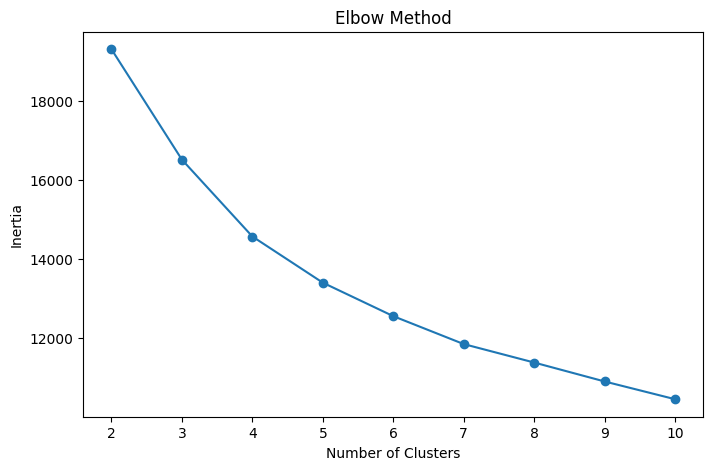

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [ ]:
# Silhouette Score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features,labels)
    silhouette_scores.append(score)

    print(f"K={k} | Silhouette Score={score:.4f}")

K=2 | Silhouette Score=0.3798
K=3 | Silhouette Score=0.2331
K=4 | Silhouette Score=0.2112
K=5 | Silhouette Score=0.1943
K=6 | Silhouette Score=0.2011
K=7 | Silhouette Score=0.2014
K=8 | Silhouette Score=0.2069
K=9 | Silhouette Score=0.1707
K=10 | Silhouette Score=0.1739


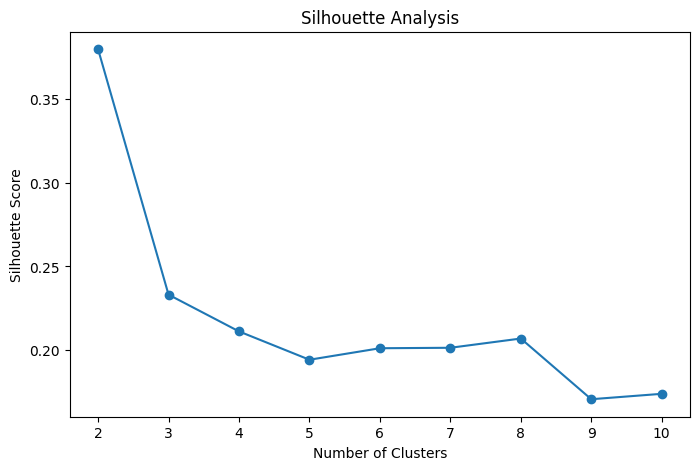

In [51]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11),silhouette_scores,marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [53]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
learner_features["Cluster"] = kmeans.fit_predict(scaled_features)

learner_features["Cluster"].value_counts()

Cluster
2    1042
0     995
3     511
1     452
Name: count, dtype: int64

In [56]:
cluster_profile = learner_features.groupby("Cluster").agg({
    "total_courses":"mean",
    "total_spending":"mean",
    "avg_spending":"mean",
    "diversity_score":"mean",
    "avg_course_rating":"mean",
    "user_age":"mean"
}).round(2)

cluster_profile

,total_courses,total_spending,avg_spending,diversity_score,avg_course_rating,user_age
Cluster,,,,,,
0,1.54,54.31,26.41,1.48,3.19,25.00
1,13.42,1252.53,93.53,8.75,3.11,24.92
2,1.60,67.60,31.34,1.53,3.17,25.08
3,1.44,431.91,326.48,1.40,2.96,24.75


In [57]:
learner_features.groupby("Cluster")["preferred_category"].agg(lambda x: x.value_counts().index[0])

Cluster
0    2
1    0
2    2
3    0
Name: preferred_category, dtype: int64

In [58]:
learner_features.groupby("Cluster")["preferred_level"].agg(lambda x: x.value_counts().index[0])

Cluster
0    0
1    0
2    0
3    1
Name: preferred_level, dtype: int64

In [61]:
cluster_names = {
    0: "Casual Learners",
    1: "Explorer Learners",
    2: "Budget Learners",
    3: "Premium Specialists"
}

learner_features["Segment"] = (learner_features["Cluster"].map(cluster_names))

learner_features[["Cluster","Segment"]].head()

,Cluster,Segment
UserID,,
U00001,3,Premium Specialists
U00002,2,Budget Learners
U00003,1,Explorer Learners
U00004,1,Explorer Learners
U00005,0,Casual Learners


In [62]:
learner_features["Segment"].value_counts()

Segment
Budget Learners        1042
Casual Learners         995
Premium Specialists     511
Explorer Learners       452
Name: count, dtype: int64

In [63]:
print(dict(zip(le_category.transform(le_category.classes_),le_category.classes_)))

{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6), np.int64(7): np.int64(7), np.int64(8): np.int64(8), np.int64(9): np.int64(9), np.int64(10): np.int64(10), np.int64(11): np.int64(11)}


In [64]:
print(dict(zip(le_level.transform(le_level.classes_),le_level.classes_)))

{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


In [72]:
learner_features.head()

,total_courses,total_spending,avg_spending,diversity_score,preferred_category,preferred_level,avg_course_rating,user_age,user_gender,Cluster,Segment
UserID,,,,,,,,,,,
U00001,1,394.26,394.260000,1,2,2,1.350000,15,1,3,Premium Specialists
U00002,1,0.00,0.000000,1,9,1,2.880000,29,0,2,Budget Learners
U00003,11,613.98,55.816364,7,8,0,2.889091,33,0,1,Explorer Learners
U00004,13,982.05,75.542308,8,5,2,3.451538,23,0,1,Explorer Learners
U00005,2,346.71,173.355000,2,9,0,2.055000,21,1,0,Casual Learners


In [76]:

[col for col in master_df.columns if "Segment" in col]


['Segment_x', 'Segment_y', 'Segment']